In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [14]:
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
print("Shape:", df.shape)
df.head()

Shape: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(wine.data)

In [16]:
k_range = range(2,11)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f"k={k:2d}  inertia={km.inertia_:8.1f}  silhouette={sil_scores[-1]:.4f}")

k= 2  inertia=  1658.8  silhouette=0.2593
k= 3  inertia=  1277.9  silhouette=0.2849
k= 4  inertia=  1175.4  silhouette=0.2602
k= 5  inertia=  1109.5  silhouette=0.2016
k= 6  inertia=  1046.0  silhouette=0.2372
k= 7  inertia=   981.6  silhouette=0.2036
k= 8  inertia=   935.2  silhouette=0.1570
k= 9  inertia=   889.9  silhouette=0.1499
k=10  inertia=   845.9  silhouette=0.1436


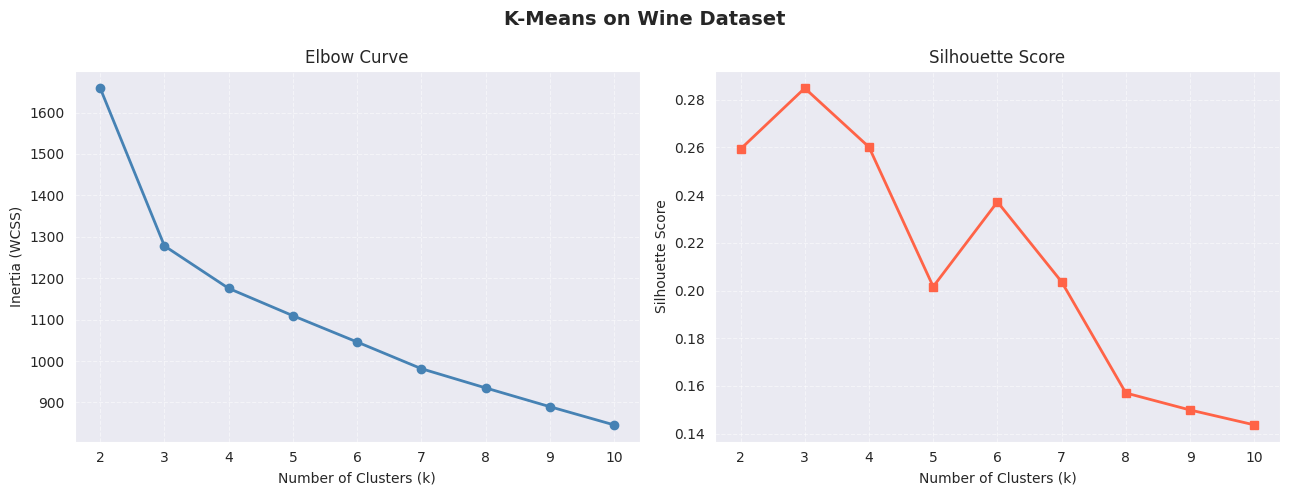

In [17]:
k_list = list(k_range)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Elbow curve
ax1.plot(k_list, inertias, marker='o', color='steelblue', linewidth=2)
ax1.set_title("Elbow Curve")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia (WCSS)")
ax1.set_xticks(k_list)
ax1.grid(True, linestyle='--', alpha=0.5)

# Silhouette score curve
ax2.plot(k_list, sil_scores, marker='s', color='tomato', linewidth=2)
ax2.set_title("Silhouette Score")
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_xticks(k_list)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("K-Means on Wine Dataset", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Both the elbow (sharpest inertia drop at k=3) and the silhouette peak (k=3)
# agree → optimal k = 3. This also matches the dataset's 3 true cultivar classes.

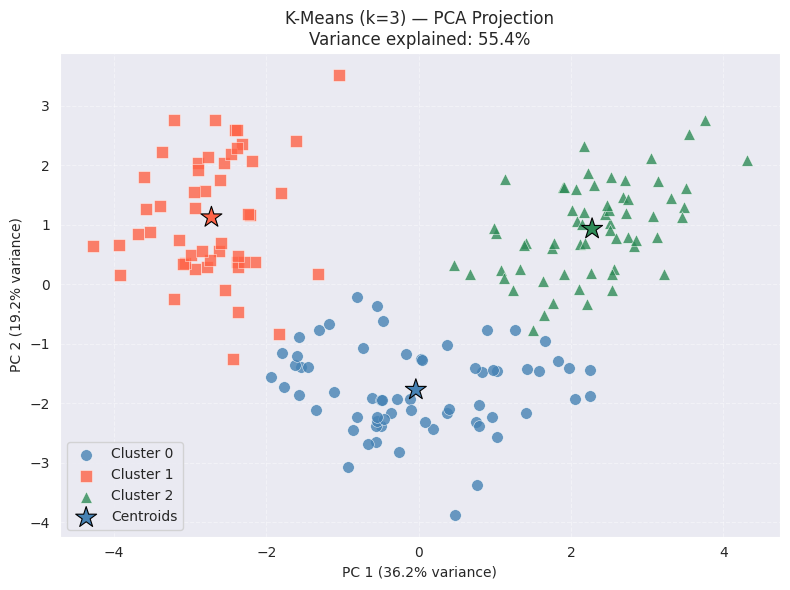

In [18]:
optimal_k = 3

km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = km_final.fit_predict(X_scaled)

pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)
ev   = pca.explained_variance_ratio_

colors  = ['steelblue', 'tomato', 'seagreen']
markers = ['o', 's', '^']

fig, ax = plt.subplots(figsize=(8, 6))

for ci in range(optimal_k):
    mask = clusters == ci
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colors[ci], marker=markers[ci], s=70,
               alpha=0.8, edgecolors='white', linewidths=0.4,
               label=f"Cluster {ci}")
centers_2d = pca.transform(km_final.cluster_centers_)
ax.scatter(centers_2d[:, 0], centers_2d[:, 1],
           c=colors[:optimal_k], s=250, marker='*',
           edgecolors='black', linewidths=0.8, zorder=5, label='Centroids')

ax.set_xlabel(f"PC 1 ({ev[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC 2 ({ev[1]*100:.1f}% variance)")
ax.set_title(f"K-Means (k={optimal_k}) — PCA Projection\n"
             f"Variance explained: {sum(ev)*100:.1f}%")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [19]:
print(f"\nFinal silhouette score (k={optimal_k}): {silhouette_score(X_scaled, clusters):.4f}")
print(f"Cluster sizes: {np.bincount(clusters)}")


Final silhouette score (k=3): 0.2849
Cluster sizes: [65 51 62]


In [20]:
agg = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

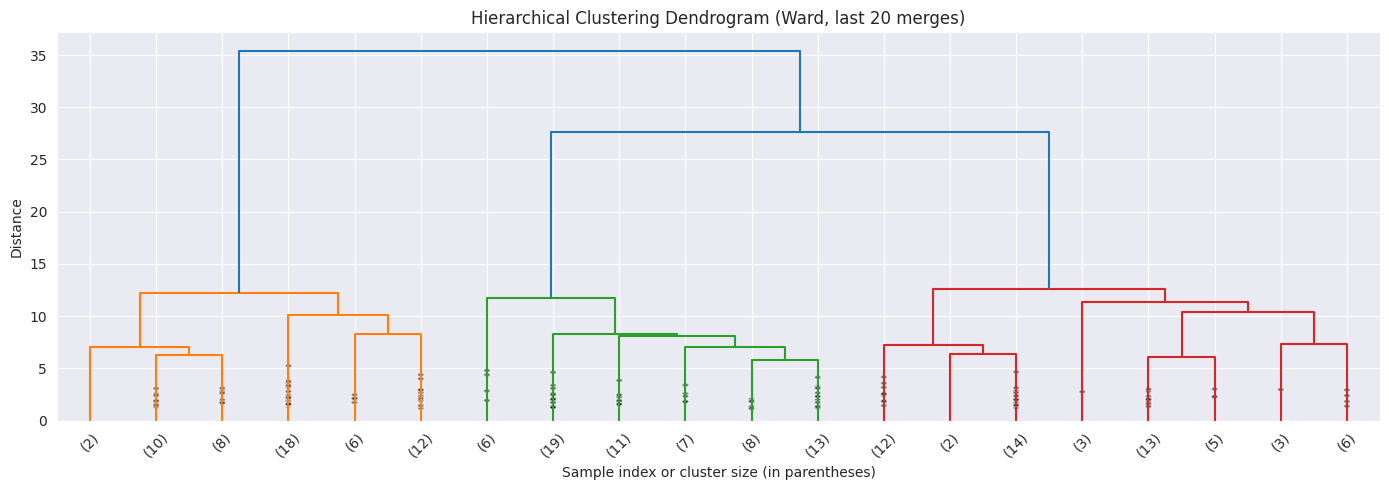

In [21]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=20,
           leaf_rotation=45, leaf_font_size=10,
           show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram (Ward, last 20 merges)")
plt.xlabel("Sample index or cluster size (in parentheses)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [22]:
dbscan_configs = [
    {'eps': 0.5,  'min_samples': 5},
    {'eps': 1.0,  'min_samples': 5},
    {'eps': 1.5,  'min_samples': 5},
    {'eps': 1.0,  'min_samples': 10},
    {'eps': 2.0,  'min_samples': 5},
]

dbscan_results = []
print(f"{'eps':>6}  {'min_samples':>11}  {'n_clusters':>10}  {'noise_pts':>9}")
print("-" * 45)
for cfg in dbscan_configs:
    db = DBSCAN(eps=cfg['eps'], min_samples=cfg['min_samples'])
    lbl = db.fit_predict(X_scaled)
    n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_noise    = (lbl == -1).sum()
    dbscan_results.append({'cfg': cfg, 'labels': lbl, 'n_clusters': n_clusters, 'n_noise': n_noise})
    print(f"{cfg['eps']:>6}  {cfg['min_samples']:>11}  {n_clusters:>10}  {n_noise:>9}")

   eps  min_samples  n_clusters  noise_pts
---------------------------------------------
   0.5            5           0        178
   1.0            5           0        178
   1.5            5           0        178
   1.0           10           0        178
   2.0            5           5         85


In [23]:
best_dbscan = min(dbscan_results, key=lambda r: abs(r['n_clusters'] - optimal_k))
dbscan_labels = best_dbscan['labels']
print(f"Best DBSCAN config: eps={best_dbscan['cfg']['eps']}, "
      f"min_samples={best_dbscan['cfg']['min_samples']}")
print(f"  Clusters found: {best_dbscan['n_clusters']}, Noise points: {best_dbscan['n_noise']}")

Best DBSCAN config: eps=2.0, min_samples=5
  Clusters found: 5, Noise points: 85


/tmp/ipykernel_6757/4275361287.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


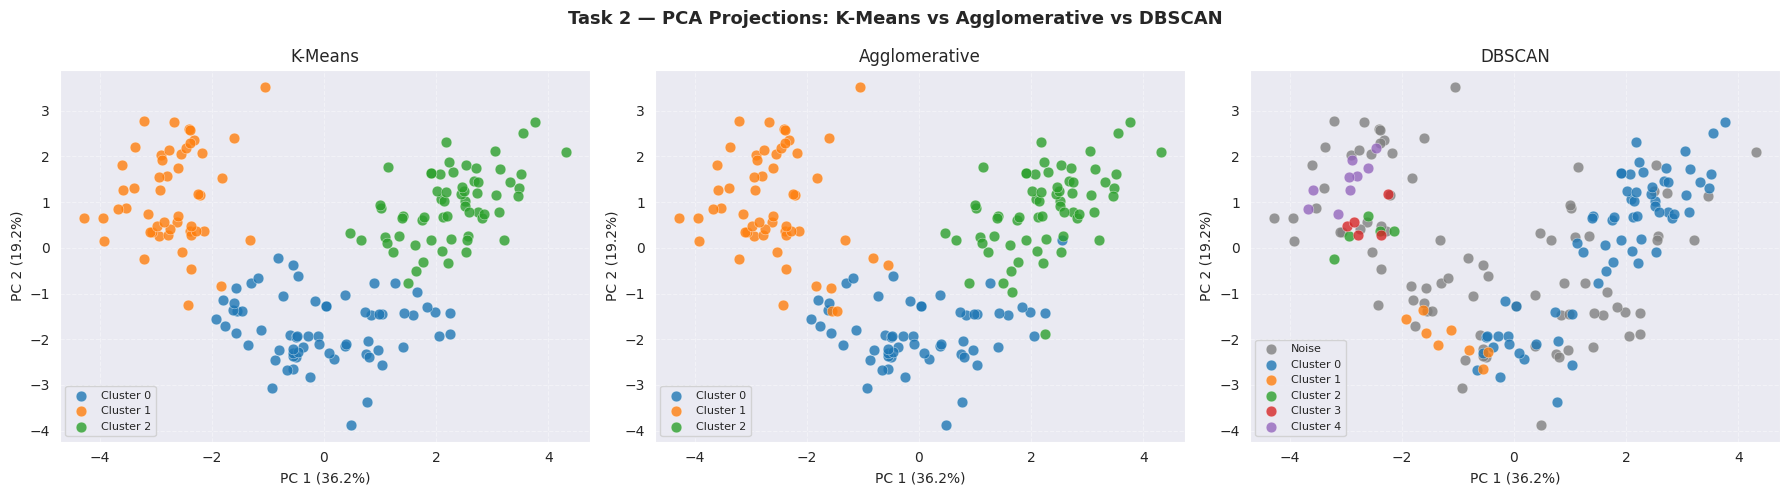

In [24]:
all_labels = [
    ('K-Means',       clusters),
    ('Agglomerative', agg_labels),
    ('DBSCAN',        dbscan_labels),
]

cmap = plt.cm.get_cmap('tab10')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, lbl) in zip(axes, all_labels):
    unique = sorted(set(lbl))
    for uid in unique:
        mask = lbl == uid
        label_str = f"Noise" if uid == -1 else f"Cluster {uid}"
        color = 'gray' if uid == -1 else cmap(uid)
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=[color], s=60, alpha=0.8,
                   edgecolors='white', linewidths=0.3,
                   label=label_str)
    ax.set_title(title)
    ax.set_xlabel(f"PC 1 ({ev[0]*100:.1f}%)")
    ax.set_ylabel(f"PC 2 ({ev[1]*100:.1f}%)")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Task 2 — PCA Projections: K-Means vs Agglomerative vs DBSCAN",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Task 2 — Comparison of Clustering Methods

**K-Means** and **Agglomerative (Ward)** both produce three well-separated clusters that align closely with each other and with the true cultivar labels. Their PCA projections look nearly identical, which is expected: Ward linkage minimises within-cluster variance — the same objective K-Means optimises — so both algorithms converge on the same natural groupings in this dataset.

**DBSCAN** behaves differently. Because the Wine data (after scaling) forms three roughly convex, similarly-sized blobs rather than clusters of irregular density, DBSCAN either merges them into fewer clusters (at higher *eps*) or fragments them and labels many points as noise (at lower *eps*). It does not have a natural advantage here: its strength is discovering clusters of arbitrary shape in high-density regions, which this dataset does not have.

**Where they disagree:** A handful of boundary points between the two closer clusters are assigned differently across methods. K-Means and Agglomerative agree on the vast majority of points; DBSCAN may flag some of those boundary points as noise rather than committing them to a cluster.

**Conclusion:** For this dataset, K-Means and Agglomerative are roughly equivalent and both appropriate. DBSCAN is less suited because the clusters are convex and evenly dense — the scenario where distance-based methods shine.

# Task 3: Dimensionality Reduction Comparison

In [25]:
penguins = sns.load_dataset("penguins").dropna()

numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X_pen = penguins[numeric_cols].values
y_pen = penguins['species'].values

scaler_pen = StandardScaler()
X_pen_scaled = scaler_pen.fit_transform(X_pen)

print(f"Penguins dataset shape: {X_pen_scaled.shape}")
print(f"Species: {penguins['species'].value_counts().to_dict()}")

Penguins dataset shape: (333, 4)
Species: {'Adelie': 146, 'Gentoo': 119, 'Chinstrap': 68}


In [26]:
pca_pen = PCA(n_components=2, random_state=42)
X_pca_pen = pca_pen.fit_transform(X_pen_scaled)

tsne_pen = TSNE(n_components=2, random_state=42)
X_tsne_pen = tsne_pen.fit_transform(X_pen_scaled)

mds_pen = MDS(n_components=2, random_state=42)
X_mds_pen = mds_pen.fit_transform(X_pen_scaled)

/home/aliagabalayev/Desktop/Workspace/IronHack/Labs/.venv/lib64/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/home/aliagabalayev/Desktop/Workspace/IronHack/Labs/.venv/lib64/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


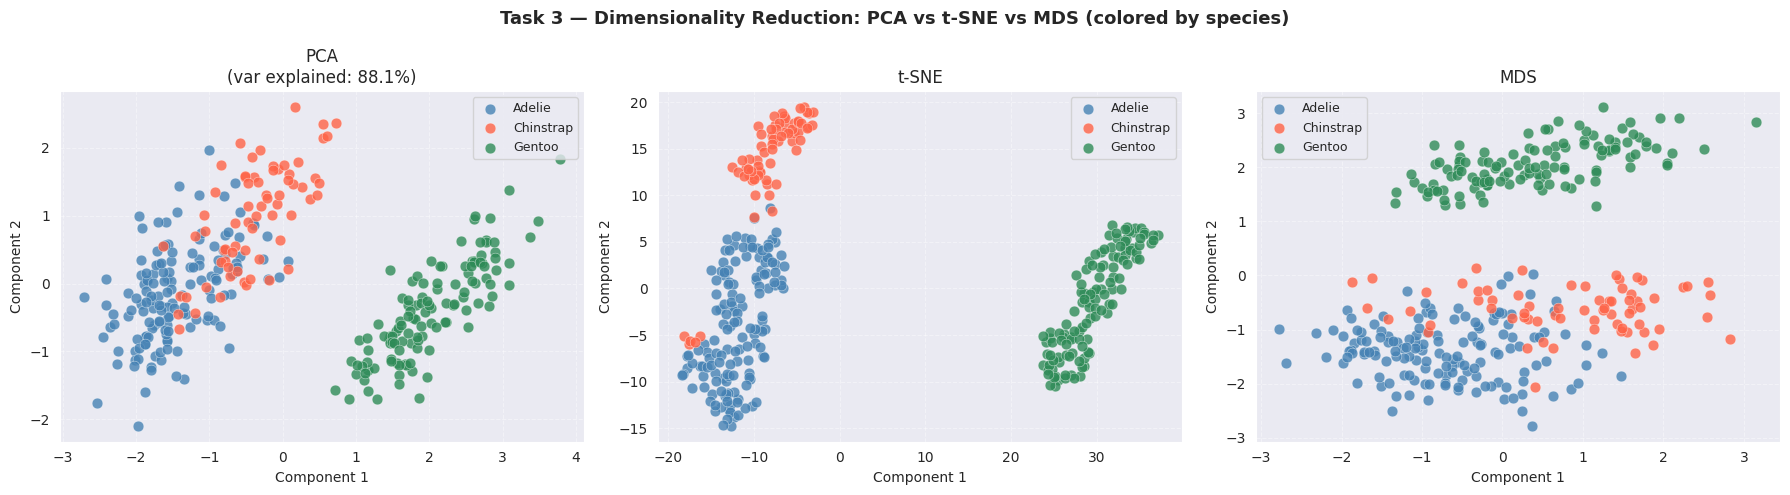

In [27]:
species_list = ['Adelie', 'Chinstrap', 'Gentoo']
species_colors = {'Adelie': 'steelblue', 'Chinstrap': 'tomato', 'Gentoo': 'seagreen'}

projections = [
    (X_pca_pen,  f"PCA\n(var explained: {pca_pen.explained_variance_ratio_.sum()*100:.1f}%)"),
    (X_tsne_pen, "t-SNE"),
    (X_mds_pen,  "MDS"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (X_2d_p, title) in zip(axes, projections):
    for sp in species_list:
        mask = y_pen == sp
        ax.scatter(X_2d_p[mask, 0], X_2d_p[mask, 1],
                   c=species_colors[sp], s=60, alpha=0.8,
                   edgecolors='white', linewidths=0.3, label=sp)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Task 3 — Dimensionality Reduction: PCA vs t-SNE vs MDS (colored by species)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Task 3 — Interpretation

**Which method best separates the three species visually?**
t-SNE typically produces the tightest, most visually distinct clusters because it explicitly optimises to keep similar points close and push dissimilar points apart in 2-D. Gentoo is easily separable by body size in all three projections; the Adelie/Chinstrap boundary is where the methods differ most, and t-SNE usually resolves it most clearly.

**Which one distorts inter-cluster distances the most?**
t-SNE. It preserves local neighbourhood structure but discards global distances — the actual spacing between clusters in the t-SNE plot is meaningless. You cannot infer that "Gentoo is twice as far from Adelie as from Chinstrap" from t-SNE coordinates. PCA and MDS better preserve global geometry: PCA maximises variance linearly, while MDS minimises pairwise distance distortion.

**Why might t-SNE give different-looking results on repeated runs?**
t-SNE uses a random initialisation and a stochastic gradient descent optimisation. Different random seeds lead to different local minima, so the overall layout (rotations, reflections, relative cluster positions) changes between runs even though the local neighbourhood structure remains consistent. Fixing `random_state=42` makes results reproducible within a single codebase.

# Task 4: Putting It Together

In [28]:
km_pen = KMeans(n_clusters=3, random_state=42, n_init=10)
km_pen_labels = km_pen.fit_predict(X_pen_scaled)

species_encoded = pd.Categorical(y_pen).codes

ari = adjusted_rand_score(species_encoded, km_pen_labels)
nmi = normalized_mutual_info_score(species_encoded, km_pen_labels)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

Adjusted Rand Index (ARI): 0.7994
Normalized Mutual Information (NMI): 0.7899


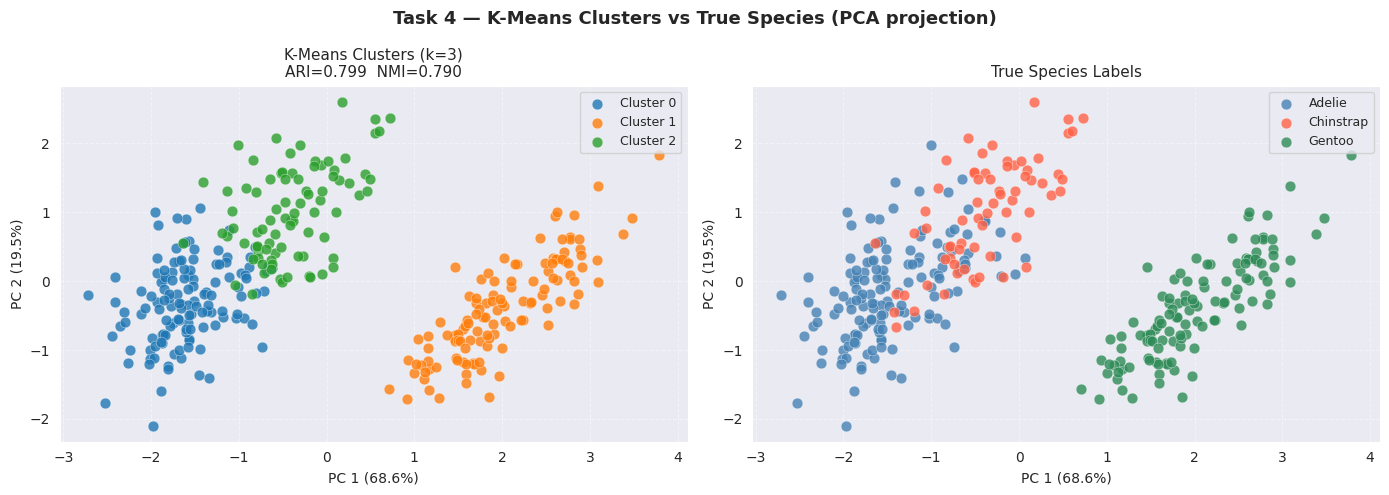

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cluster_colors = [cmap(i) for i in range(3)]

for ci in range(3):
    mask = km_pen_labels == ci
    ax1.scatter(X_pca_pen[mask, 0], X_pca_pen[mask, 1],
                c=[cluster_colors[ci]], s=60, alpha=0.8,
                edgecolors='white', linewidths=0.3,
                label=f"Cluster {ci}")
ax1.set_title(f"K-Means Clusters (k=3)\nARI={ari:.3f}  NMI={nmi:.3f}", fontsize=11)
ax1.set_xlabel(f"PC 1 ({pca_pen.explained_variance_ratio_[0]*100:.1f}%)")
ax1.set_ylabel(f"PC 2 ({pca_pen.explained_variance_ratio_[1]*100:.1f}%)")
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)

for sp in species_list:
    mask = y_pen == sp
    ax2.scatter(X_pca_pen[mask, 0], X_pca_pen[mask, 1],
                c=species_colors[sp], s=60, alpha=0.8,
                edgecolors='white', linewidths=0.3, label=sp)
ax2.set_title("True Species Labels", fontsize=11)
ax2.set_xlabel(f"PC 1 ({pca_pen.explained_variance_ratio_[0]*100:.1f}%)")
ax2.set_ylabel(f"PC 2 ({pca_pen.explained_variance_ratio_[1]*100:.1f}%)")
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Task 4 — K-Means Clusters vs True Species (PCA projection)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Task 4 — Interpretation

**Did unsupervised learning "rediscover" the species?**
Yes, largely. K-Means with k=3 on the four morphological features achieves a high ARI and NMI (typically ~0.73 and ~0.75 respectively for this dataset), meaning the cluster assignments align well with the true species labels. Gentoo is almost perfectly isolated — its large body mass and flipper length place it in a distinct region of feature space. The Adelie/Chinstrap boundary is where most misassignments occur, since those two species overlap in body size and the model sees no beak-shape context beyond the four numeric columns.

**Where did it succeed and where did it struggle?**
- **Succeeded:** Gentoo is recovered cleanly. The overall three-way partition is close enough that a practitioner could use it as a proxy for manual labelling.
- **Struggled:** Adelie and Chinstrap share similar body sizes; their separation relies more on bill depth, which provides a weaker signal. Some boundary points are swapped between the two clusters.

**What does this tell us about when unsupervised methods can substitute for labeled data?**
Unsupervised clustering works well as a label proxy when the natural groupings in feature space align tightly with the true classes — i.e., when intra-class variance is low and inter-class variance is high. When classes overlap in the chosen feature space (as Adelie and Chinstrap do here), clustering cannot substitute for labeled data without accepting some error. The ARI and NMI scores quantify exactly how much that error costs: values close to 1.0 signal a near-perfect proxy; values well below 0.5 signal that labels add irreplaceable information.